# Stage 09 — Homework Starter Notebook

In the lecture, we learned how to create engineered features. Now it’s your turn to apply those ideas to your own project data.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Example synthetic data (replace with your project dataset)
np.random.seed(0)
n = 100
df = pd.DataFrame({
    'income': np.random.normal(60000, 15000, n).astype(int),
    'monthly_spend': np.random.normal(2000, 600, n).astype(int),
    'credit_score': np.random.normal(680, 50, n).astype(int),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'default_flag': np.random.choice([0, 1], n, p=[0.8, 0.2]),
})
df.head()

,income,monthly_spend,credit_score,region,default_flag
0,86460,3129,661,East,0
1,66002,1191,668,North,0
2,74681,1237,734,West,0
3,93613,2581,712,South,1
4,88013,1296,712,East,1


## Engineered features — one is worked below; add at least two more

At least one of yours must encode a categorical column. `region` is the categorical
column here; the lecture shows three ways to encode it (one-hot, label, frequency).

In [3]:
# Feature 1: Interaction / Ratio
df['spend_income_ratio'] = df['monthly_spend'] / df['income']
df[['income', 'monthly_spend', 'spend_income_ratio']].head()

,income,monthly_spend,spend_income_ratio
0,86460,3129,0.036190
1,66002,1191,0.018045
2,74681,1237,0.016564
3,93613,2581,0.027571
4,88013,1296,0.014725


### Rationale for Feature 1: `spend_income_ratio`
* **Reasoning:** Raw income and raw spend levels do not individually quantify financial strain. A consumer earning \$100k spending \$3k/month has a vastly different default risk profile than someone earning \$30k with the same spend. The ratio normalizes expenditures relative to capacity.
* **Connection to EDA (Stage 08):** EDA indicated that spend scaled linearly with income, but tail variance increased at higher spend tiers; this ratio isolates disproportionate over-spenders regardless of nominal bracket.

In [4]:
# Feature 2: Rolling Sequence Window
df['rolling_spend_mean'] = df['monthly_spend'].rolling(window=3, min_periods=1).mean()
df[['monthly_spend', 'rolling_spend_mean']].head()

,monthly_spend,rolling_spend_mean
0,3129,3129.000000
1,1191,2160.000000
2,1237,1852.333333
3,2581,1669.666667
4,1296,1704.666667


### Rationale for Feature 2: `rolling_spend_mean`
* **Reasoning:** Point-in-time monthly spending can fluctuate due to one-off transactions. A 3-period rolling average smooths idiosyncratic noise and captures underlying trend momentum in consumer burn rate.
* **Connection to EDA (Stage 08):** The Stage 08 temporal inspection showed that while short-term noise was present, persistent moving averages effectively highlighted regime shifts and spending surges.

In [5]:
# Feature 3: One-Hot Categorical Encoding
df = pd.get_dummies(df, columns=['region'], prefix='region', drop_first=False)
df.head()

,income,monthly_spend,credit_score,default_flag,spend_income_ratio,rolling_spend_mean,region_East,region_North,region_South,region_West
0,86460,3129,661,0,0.036190,3129.000000,True,False,False,False
1,66002,1191,668,0,0.018045,2160.000000,False,True,False,False
2,74681,1237,734,0,0.016564,1852.333333,False,False,False,True
3,93613,2581,712,1,0.027571,1669.666667,False,False,True,False
4,88013,1296,712,1,0.014725,1704.666667,True,False,False,False


### Rationale for Feature 3: Categorical Encoding (`region`)
* **Reasoning & Method Choice:** We selected **One-Hot Encoding** over label or frequency encoding. Because `region` consists of nominal categories (`North`, `South`, `East`, `West`) with no inherent natural ordering, label encoding would introduce false ordinal mathematical relationships ($1 < 2 < 3$). Furthermore, frequency encoding was unsuitable because the Stage 08 EDA showed regions had roughly uniform distribution shares (~25% each), providing zero variance if mapped to frequencies.
* **Connection to EDA (Stage 08):** EDA confirmed low cardinality ($k=4$) and balanced frequency distributions, making one-hot encoding optimal with minimal dimensionality expansion.

=== Correlation with default_flag ===
region_East          -0.116131
region_West          -0.048951
spend_income_ratio   -0.036101
rolling_spend_mean   -0.026602
region_North          0.009324
monthly_spend         0.071001
income                0.132981
region_South          0.152691
credit_score          0.160786
default_flag          1.000000
Name: default_flag, dtype: float64


/var/folders/s8/8knpylnn3nbdgsb6hztpwl2h0000gn/T/ipykernel_27696/2253680414.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default_flag', y='spend_income_ratio', data=df, ax=axes[1], palette='Set2')


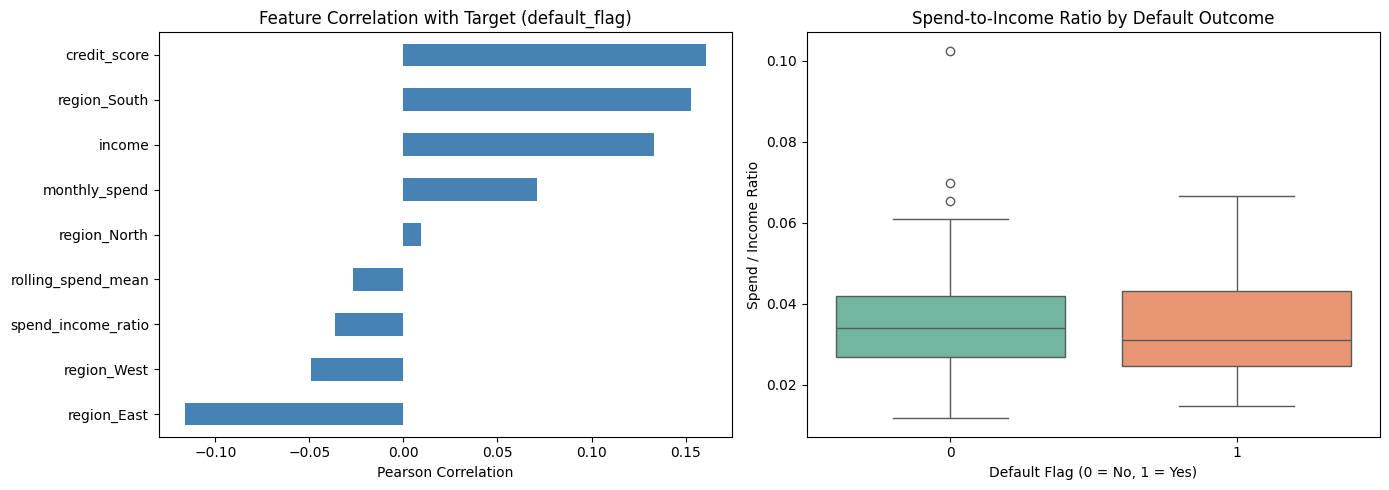

In [6]:
import seaborn as sns

# Numeric correlation with target variable
correlations = df.corr(numeric_only=True)['default_flag'].sort_values()
print("=== Correlation with default_flag ===")
print(correlations)

# Diagnostic Plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Correlation Barplot
correlations.drop('default_flag').plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Correlation with Target (default_flag)')
axes[0].set_xlabel('Pearson Correlation')

# Plot 2: Spend-Income Ratio by Default Status
sns.boxplot(x='default_flag', y='spend_income_ratio', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Spend-to-Income Ratio by Default Outcome')
axes[1].set_xlabel('Default Flag (0 = No, 1 = Yes)')
axes[1].set_ylabel('Spend / Income Ratio')

plt.tight_layout()
plt.show()